In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

import pickle

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV

import joblib

from sklearn.metrics import roc_curve, roc_auc_score



### Data Exploration/Cleaning

In [4]:
df =pd.concat(
    [
pd.read_csv('customer_churn_dataset-testing-master.csv'),
pd.read_csv('customer_churn_dataset-training-master.csv')
]
)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.0,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.0,18.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505207 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


In [6]:
df.describe(include='all')

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206,505206.000000,505206.000000,505206.000000,505206.000000,505206,505206,505206.000000,505206.000000,505206.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,Standard,Annual,NaN,NaN,NaN
freq,NaN,NaN,280273,NaN,NaN,NaN,NaN,170630,198608,NaN,NaN,NaN
mean,200779.451782,39.704172,NaN,31.350435,15.714825,3.833317,13.496843,NaN,NaN,620.072766,14.610581,0.555203
std,137241.343095,12.670577,NaN,17.237482,8.619323,3.133603,8.451187,NaN,NaN,245.319256,8.608286,0.496944
min,1.000000,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,NaN,16.000000,8.000000,1.000000,6.000000,NaN,NaN,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,NaN,32.000000,16.000000,3.000000,13.000000,NaN,NaN,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,NaN,46.000000,23.000000,6.000000,20.000000,NaN,NaN,824.000000,22.000000,1.000000


In [7]:
#Identifying any missing values
null_rows_df = df[df.isnull().any(axis=1)]
null_rows_df


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Drop the singular row with missing values
df.dropna(inplace=True)

In [9]:
#Modify the text of the columns to match formatting
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns={'customerid': 'customer_id'})


In [10]:
# Map the churn column of 0s and 1s to Yes and No for visualization
mapping_dict_binary = {1: 'yes', 0: 'no'}
df['churn_labeled'] = df['churn'].map(mapping_dict_binary)
df.head()

,customer_id,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn,churn_labeled
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0,yes
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0,no
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0,no
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.0,18.0,0.0,no
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.0,18.0,0.0,no


### Exploratory Data Analysis

In [11]:
numeric_columns_data=df.select_dtypes(include='number')

In [12]:
numeric_columns_data.corr()

,customer_id,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,churn
customer_id,1.000000,-0.178442,0.031444,0.043649,-0.476560,-0.282815,0.347573,-0.121668,-0.650617
age,-0.178442,1.000000,-0.010078,-0.013551,0.146790,0.060569,-0.078679,0.027472,0.191224
tenure,0.031444,-0.010078,1.000000,-0.020686,-0.013381,-0.004400,0.015810,-0.004726,-0.021308
usage_frequency,0.043649,-0.013551,-0.020686,1.000000,-0.025947,-0.012667,0.019573,-0.006358,-0.053263
support_calls,-0.476560,0.146790,-0.013381,-0.025947,1.000000,0.176038,-0.206566,0.074070,0.516283
payment_delay,-0.282815,0.060569,-0.004400,-0.012667,0.176038,1.000000,-0.125975,0.041767,0.329785
total_spend,0.347573,-0.078679,0.015810,0.019573,-0.206566,-0.125975,1.000000,-0.054560,-0.369682
last_interaction,-0.121668,0.027472,-0.004726,-0.006358,0.074070,0.041767,-0.054560,1.000000,0.127150
churn,-0.650617,0.191224,-0.021308,-0.053263,0.516283,0.329785,-0.369682,0.127150,1.000000


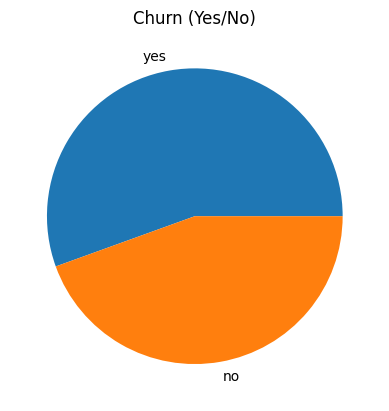

In [13]:
df['churn_labeled'].value_counts().plot(kind='pie')
plt.title('Churn (Yes/No)')
plt.ylabel('')
plt.show()

There is slightly larger proportion of customers who have churned.

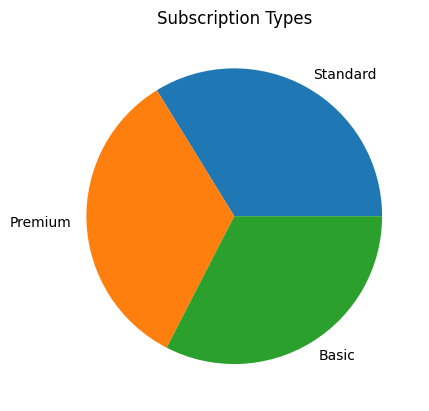

In [14]:
df['subscription_type'].value_counts().plot(kind='pie')
plt.title('Subscription Types')
plt.ylabel('')
plt.show()

There is a close balance between the three different subscription types.

In [15]:
#Compute the average spending for both churning and non-churning customers
df.groupby('churn_labeled')['total_spend'].mean()

churn_labeled
no     721.394858
yes    538.899354
Name: total_spend, dtype: float64

In [16]:
df.groupby(['churn_labeled', 'gender'])['total_spend'].mean()

churn_labeled  gender
no             Female    715.449816
               Male      724.615745
yes            Female    539.433514
               Male      538.319744
Name: total_spend, dtype: float64

In [17]:
df.groupby('churn_labeled')['tenure'].mean()

churn_labeled
no     31.760789
yes    31.021683
Name: tenure, dtype: float64

In [18]:
df.groupby('churn_labeled')['age'].mean()

churn_labeled
no     36.997201
yes    41.872841
Name: age, dtype: float64

In [19]:
df.groupby('subscription_type')['total_spend'].mean()

subscription_type
Basic       617.227238
Premium     621.675034
Standard    621.218400
Name: total_spend, dtype: float64

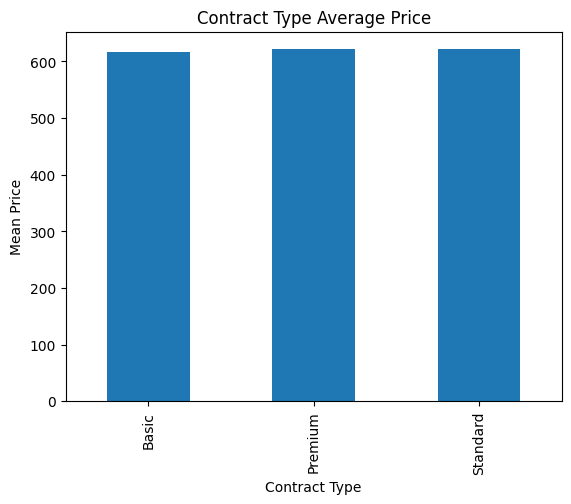

In [20]:
df.groupby('subscription_type')['total_spend'].mean().plot(kind='bar')
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")
plt.title("Contract Type Average Price")
plt.show()

At the basic and premium subscription levels, we can see that the average spending for consumers is lower than the standard subscription.

In [21]:
df.groupby('contract_length')['total_spend'].mean()

contract_length
Annual       639.041546
Monthly      550.481073
Quarterly    639.500967
Name: total_spend, dtype: float64

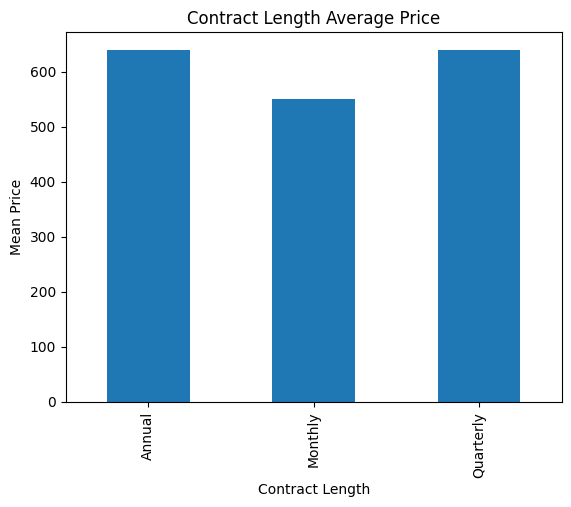

In [22]:
df.groupby('contract_length')['total_spend'].mean().plot(kind='bar')
plt.ylabel("Mean Price")
plt.xlabel("Contract Length")
plt.title("Contract Length Average Price")
plt.show()

Monthly contract lengths have the lowest average price, with annual and quarterly being higher and close to equal.

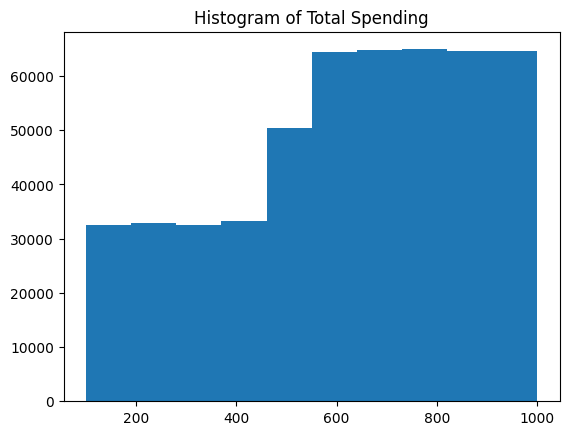

In [23]:
plt.hist(df['total_spend'])
plt.title('Histogram of Total Spending')
plt.show()

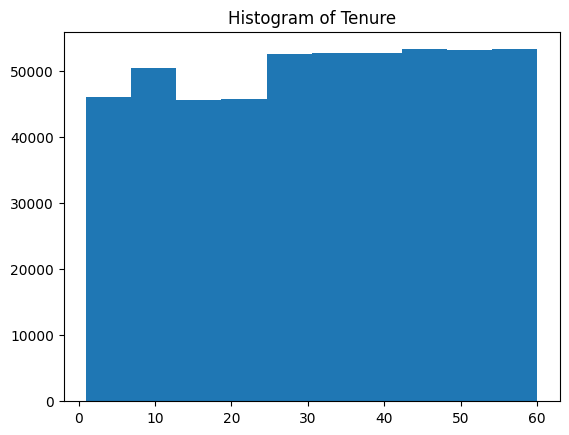

In [24]:
plt.hist(df['tenure'])
plt.title('Histogram of Tenure')
plt.show()

#### Are there noticeable patterns in payment delay regarding churn rate among customers?

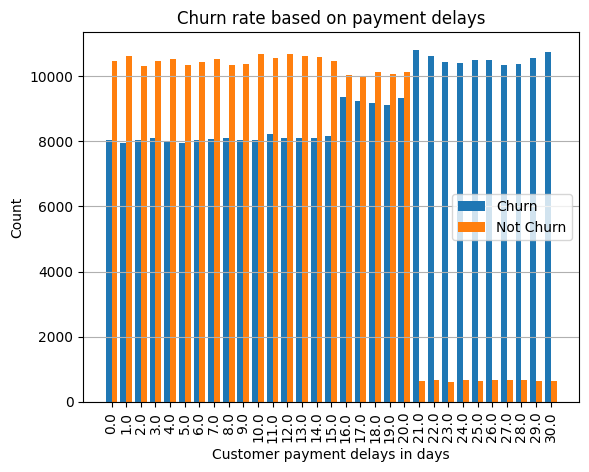

In [25]:
filtered = df.groupby(['payment_delay', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer payment delays in days")
plt.ylabel('Count')
plt.title("Churn rate based on payment delays")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

Before day 20, customers who are not churned tend to have higher payment delay days compared to churned customers. Afterwards, churned customers have payment delays just over 10 times than that of not churned customers.

#### Does subscription type affect churn rate?

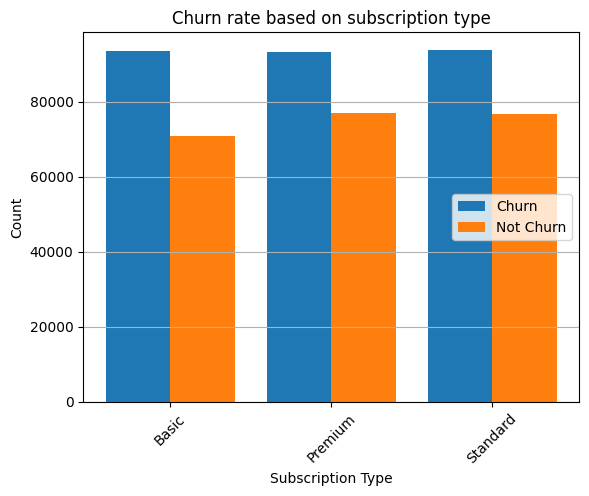

In [26]:
filtered = df.groupby(['subscription_type', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.title("Churn rate based on subscription type")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

No, customers who are not churned choose premium or standard subscriptions.

#### Independent Features Correlation

In [27]:
independent_features_df = df.select_dtypes(include=['number']).copy().drop(columns=['churn'])

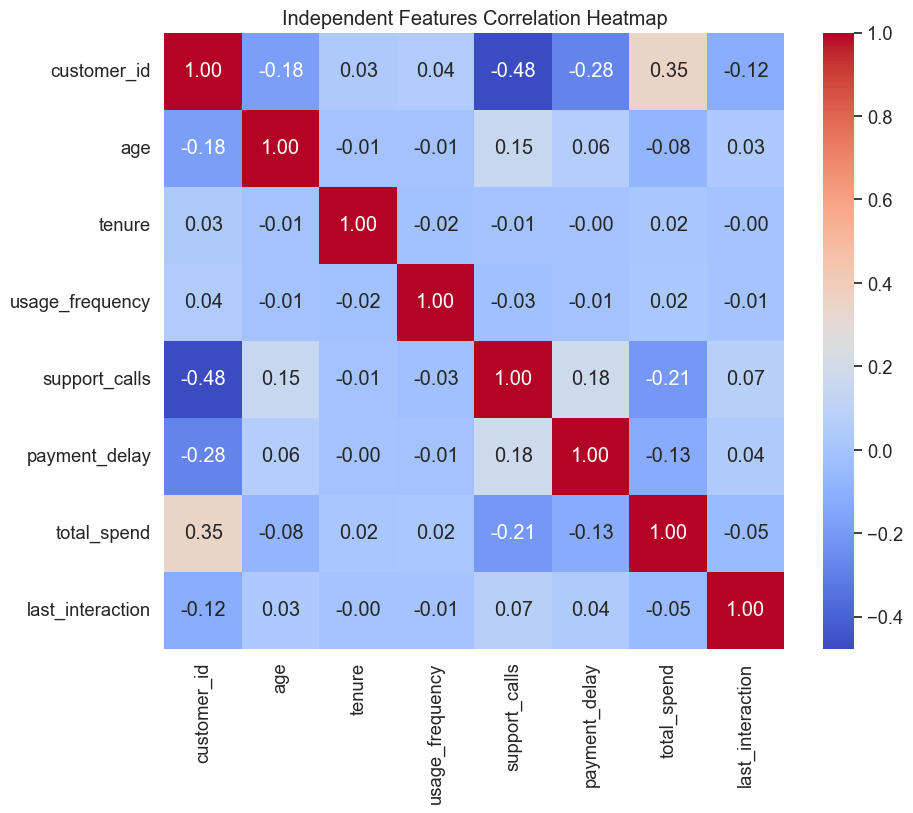

In [28]:
corr_matrix = independent_features_df.corr()

# Creating a mask to hide the upper triangle of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Independent Features Correlation Heatmap")
plt.show()

### Feature engineering, Train-Test Split

In [29]:
df.columns

Index(['customer_id', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn',
       'churn_labeled'],
      dtype='object')

In [30]:
y = df['churn'].astype(int)
X = df.drop(columns=['churn', 'churn_labeled', 'customer_id'])

In [31]:
y

0         1
1         0
2         0
3         0
4         0
         ..
440828    0
440829    0
440830    0
440831    0
440832    0
Name: churn, Length: 505206, dtype: int64

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Reset the index of the resulting DataFrames
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [33]:

X_train

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction
0,24.0,Male,10.0,6.0,9.0,25.0,Premium,Annual,167.00,12.0
1,47.0,Female,1.0,21.0,1.0,2.0,Premium,Annual,712.28,3.0
2,27.0,Female,41.0,1.0,0.0,4.0,Premium,Annual,618.83,3.0
3,40.0,Male,18.0,8.0,6.0,23.0,Standard,Quarterly,360.00,2.0
4,40.0,Male,39.0,7.0,3.0,12.0,Premium,Monthly,199.00,10.0
...,...,...,...,...,...,...,...,...,...,...
404159,40.0,Male,2.0,7.0,2.0,17.0,Standard,Quarterly,980.37,30.0
404160,37.0,Female,41.0,19.0,1.0,5.0,Premium,Annual,882.00,8.0
404161,60.0,Male,38.0,11.0,2.0,19.0,Basic,Quarterly,142.64,24.0
404162,39.0,Male,22.0,6.0,4.0,25.0,Standard,Monthly,604.00,16.0


In [34]:
X_test

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction
0,49.0,Male,41.0,27.0,5.0,26.0,Premium,Monthly,242.00,22.0
1,38.0,Female,58.0,24.0,6.0,22.0,Premium,Quarterly,108.00,11.0
2,21.0,Male,36.0,2.0,1.0,7.0,Basic,Quarterly,535.46,4.0
3,18.0,Female,56.0,4.0,3.0,10.0,Premium,Monthly,635.00,29.0
4,43.0,Male,57.0,29.0,3.0,14.0,Standard,Annual,846.74,19.0
...,...,...,...,...,...,...,...,...,...,...
101037,53.0,Female,56.0,9.0,5.0,17.0,Standard,Monthly,940.23,17.0
101038,64.0,Female,12.0,2.0,2.0,7.0,Standard,Quarterly,876.00,29.0
101039,22.0,Female,31.0,18.0,2.0,15.0,Standard,Quarterly,798.97,3.0
101040,24.0,Male,37.0,14.0,2.0,3.0,Standard,Annual,782.90,18.0


In [35]:
def validate_test_data_categorical_columns(train_df, test_df):
    # Get the list of categorical columns for both train and test DataFrames
    train_df_categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
    test_df_categorical_columns = test_df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Check if the number of categorical columns is the same in both DataFrames
    if len(set(train_df_categorical_columns).intersection(set(test_df_categorical_columns))) == 0:
        print('Train and test dataframes have different categorical columns')
        return
    else:
        for cat_col in test_df_categorical_columns:
            # Create sets of unique values for the current categorical column in both DataFrames
            train_col = set(x for x in train_df[cat_col].unique().tolist() if not pd.isna(x))
            test_col = set(x for x in test_df[cat_col].unique().tolist() if not pd.isna(x))
            
            # Check if the sets are not equal, indicating different unique values
            if train_col != test_col:
                print(f'{cat_col} column has different unique values in train and test data:')
                print(f'Unique values in train data: {train_col}')
                print(f'Unique values in test data: {test_col}')
                return
        
        print('All categorical columns have consistent unique values in train and test data.')
        return
    
validate_test_data_categorical_columns(X_train, X_test)               

All categorical columns have consistent unique values in train and test data.


In [36]:
encoder = OneHotEncoder(sparse_output=False)

encoder.fit(X_train[['gender', 'subscription_type', 'contract_length']])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [37]:
feature_names = encoder.get_feature_names_out(['gender', 'subscription_type', 'contract_length'])
feature_names

array(['gender_Female', 'gender_Male', 'subscription_type_Basic',
       'subscription_type_Premium', 'subscription_type_Standard',
       'contract_length_Annual', 'contract_length_Monthly',
       'contract_length_Quarterly'], dtype=object)

In [38]:
train_categorical_one_encoded_data = encoder.transform(X_train[['gender', 'subscription_type', 'contract_length']])
train_OHE_df = pd.DataFrame(train_categorical_one_encoded_data, columns=feature_names)

test_categorical_one_encoded_data = encoder.transform(X_test[['gender', 'subscription_type', 'contract_length']])
test_OHE_df = pd.DataFrame(test_categorical_one_encoded_data, columns=feature_names)

In [39]:
X_train = X_train.drop(columns=['gender', 'subscription_type', 'contract_length'])
X_test = X_test.drop(columns=['gender', 'subscription_type', 'contract_length'])

In [40]:
X_train = pd.concat([X_train, train_OHE_df], axis=1)
X_test = pd.concat([X_test, test_OHE_df], axis=1)

In [41]:
scaler = preprocessing.StandardScaler()

X_train= scaler.fit_transform(X_train)
X_train

array([[-1.23893259, -1.23785797, -1.12763456, ...,  1.24323221,
        -0.52592422, -0.80043455],
       [ 0.57607759, -1.76005982,  0.61347343, ...,  1.24323221,
        -0.52592422, -0.80043455],
       [-1.00219213,  0.56083729, -1.70800389, ...,  1.24323221,
        -0.52592422, -0.80043455],
       ...,
       [ 1.6019529 ,  0.38677   , -0.54726523, ..., -0.80435497,
        -0.52592422,  1.24932138],
       [-0.0552303 , -0.54158884, -1.12763456, ..., -0.80435497,
         1.90141463, -0.80043455],
       [ 0.65499107, -1.41192525, -0.19904363, ...,  1.24323221,
        -0.52592422, -0.80043455]], shape=(404164, 15))

In [42]:

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [43]:
X_test = scaler.fit_transform(X_test)

PCA

In [44]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

In [45]:

pca.explained_variance_ratio_

array([0.14155306, 0.11087934])

In [46]:
data = {
    'Feature_1': X_pca[:, 0],
    'Feature_2': X_pca[:, 1],
    'Target': y_train
}

pca_df = pd.DataFrame(data)
pca_df

,Feature_1,Feature_2,Target
0,-0.463642,1.617028,1
1,0.881731,-1.981699,0
2,0.756367,-2.215664,0
3,-0.595421,0.506800,1
4,-0.237097,2.062027,0
...,...,...,...
404159,-1.700371,-0.157566,0
404160,0.638471,-2.178817,0
404161,-0.827337,1.406511,1
404162,-0.230498,2.244336,1


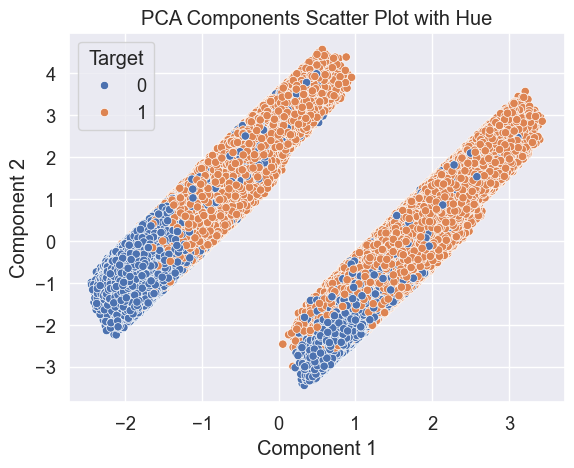

In [77]:
sns.scatterplot(data=pca_df, x='Feature_1', y='Feature_2', hue='Target')

# Set plot labels and title
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('PCA Components Scatter Plot with Hue')

# Show the plot
plt.legend(title='Target')
plt.show()

Models to Compare

In [63]:
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test, predictions)))

Logistic Regression

In [76]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Decision Tree Performance:")
modelperformance(y_pred)

Decision Tree Performance:
Accuracy score on model is 0.8477068941628234


Decision Trees

In [72]:
# Initialize model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_preds = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Performance:")
modelperformance(dt_preds)

Decision Tree Performance:
Accuracy score on model is 0.9172720254943488


Random Forest

In [73]:


rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Performance:")
modelperformance(rf_preds)

Random Forest Performance:
Accuracy score on model is 0.9348686684744958


K Nearest Neighbor

In [67]:
from sklearn.neighbors import KNeighborsClassifier

In [78]:
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test)

print("KNN Performance:")
modelperformance(knn_preds)

KNN Performance:
Accuracy score on model is 0.8978444607193048


Random Forest achieved the highest accuracy, benefiting from ensemble learning and the ability to capture complex nonlinear relationships.

Logistic Regression performed well as a baseline model, providing strong interpretability and competitive accuracy, but may not show the whole picture of variables driving churn rate.

Decision Tree showed moderate performance but is prone to overfitting, especially without depth constraints.

K-Nearest Neighbors (KNN) performed reasonably but was computationally expensive and sensitive to feature scaling.

ROC Curve Comparison

In [82]:
# Logistic Regression
log_probs = log_model.predict_proba(X_test)[:, 1]

# Decision Tree
dt_probs = dt_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# KNN (use scaled data)
knn_probs = knn_model.predict_proba(X_test)[:, 1]

In [83]:
# Logistic Regression
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
log_auc = roc_auc_score(y_test, log_probs)

# Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# KNN
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)
knn_auc = roc_auc_score(y_test, knn_probs)

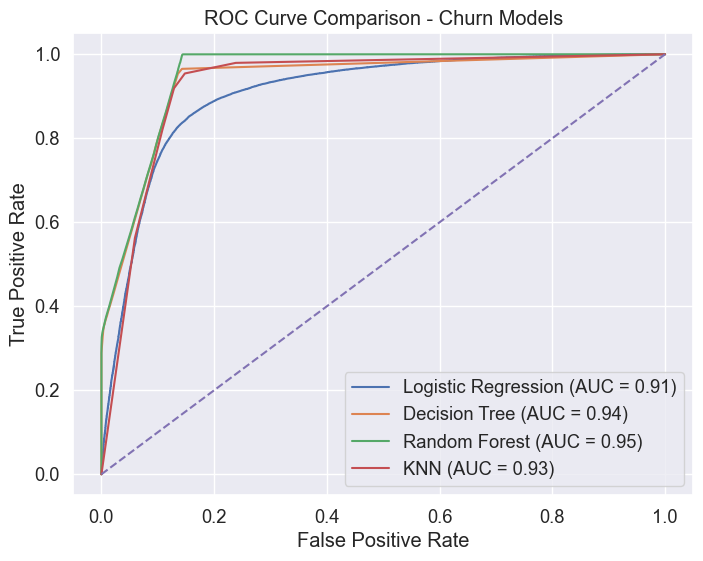

In [84]:
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.2f})')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Churn Models")
plt.legend()
plt.show()

The ROC curve comparison shows that the Random Forest model achieved the highest AUC, indicating the strongest ability to distinguish between churn and non-churn customers across different thresholds. Decision Trees and KNN showed lower AUC scores, indicating weaker classification performance.  Logistic Regression performed competitively, suggesting that linear relationships still capture meaningful churn patterns.

Rather than relying solely on accuracy, ROC-AUC was used to evaluate model performance across classification thresholds. The Random Forest model achieved the highest AUC, indicating superior discrimination between churn and non-churn customers. This makes it the most suitable model for prioritizing high-risk customers in retention strategies.